In [1]:
import torch

if torch.cuda.is_available():
    print(
        f"CUDA is available: Using {torch.cuda.device_count()} units of {torch.cuda.get_device_name(0)}"
    )
else:
    print("Using CPU")

CUDA is available: Using 2 units of Tesla T4


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertConfig, BertForMaskedLM
from transformers import Trainer, TrainingArguments
from transformers import AutoModelForSequenceClassification

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

from utils_metrics import evaluate_model_pipeline

from utils_bert import (
    FraudMLMDataset,
    FraudDataCollatorForMLM,
    FraudClassificationDataset,
    compute_metrics,
)

# 1. Data Processing

### Import data

In [3]:
try:  # Kaggle environment
    df_raw = pd.read_csv(
        "/kaggle/input/datasets/mtalaltariq/paysim-data/paysim dataset.csv"
    )
except:  # Local environment
    df_raw = pd.read_csv("data/paysim_dataset.csv")
df_raw.drop(columns=["nameOrig", "nameDest"], inplace=True)

In [4]:
df_raw.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


### Split Train, Eval, and Test, making sure the fraud distribution is balanced

In [5]:
df_raw_train, df_raw_eval_test = train_test_split(
    df_raw, test_size=0.25, random_state=42, stratify=df_raw["isFraud"]
)

df_raw_eval, df_raw_test = train_test_split(
    df_raw_eval_test,
    test_size=0.6,
    random_state=42,
    stratify=df_raw_eval_test["isFraud"],
)

In [6]:
labels_train = df_raw_train["isFraud"].to_numpy()
df_raw_train.drop(columns=["isFraud", "isFlaggedFraud"], inplace=True)

labels_eval = df_raw_eval["isFraud"].to_numpy()
df_raw_eval.drop(columns=["isFraud", "isFlaggedFraud"], inplace=True)

labels_test = df_raw_test["isFraud"].to_numpy()
df_raw_test.drop(columns=["isFraud", "isFlaggedFraud"], inplace=True)

### Helpers to turn numerical values into categories / bins
Not only this is necessary to BERT, binning the values also helps in preventing data leakage (where the model would be able to infer accounts based on exact balance values)

In [7]:
def convert_step_to_hour(step: int) -> str:
    """Convert a step value to an hour string."""
    hour = step % 24
    return f"SYNTH_HOUR_{hour:02d}"

In [8]:
df_raw_train["hour_of_transaction"] = df_raw_train["step"].apply(convert_step_to_hour)
df_raw_eval["hour_of_transaction"] = df_raw_eval["step"].apply(convert_step_to_hour)
df_raw_test["hour_of_transaction"] = df_raw_test["step"].apply(convert_step_to_hour)

df_raw_train.drop(columns=["step"], inplace=True)
df_raw_eval.drop(columns=["step"], inplace=True)
df_raw_test.drop(columns=["step"], inplace=True)

In [9]:
VALUE_BINS = [
    -np.inf,
    0,
    10_000,
    50_000,
    100_000,
    250_000,
    500_000,
    750_000,
    1_000_000,
    3_000_000,
    np.inf,
]
VALUE_LABELS = [
    "VALUE_EQUAL_0",
    "VALUE_BETWEEN_0_10K",
    "VALUE_BETWEEN_10K_50K",
    "VALUE_BETWEEN_50K_100K",
    "VALUE_BETWEEN_100K_250K",
    "VALUE_BETWEEN_250K_500K",
    "VALUE_BETWEEN_500K_750K",
    "VALUE_BETWEEN_750K_1M",
    "VALUE_BETWEEN_1M_3M",
    "VALUE_ABOVE_3M",
]


def bin_values_column(series: pd.Series) -> pd.Series:
    """Fast vectorized binning using pd.cut for whole Pandas Series."""
    return pd.cut(series, bins=VALUE_BINS, labels=VALUE_LABELS, right=True)

In [10]:
monetary_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]

# Apply binning across columns
binned_df = df_raw[monetary_cols].apply(bin_values_column)

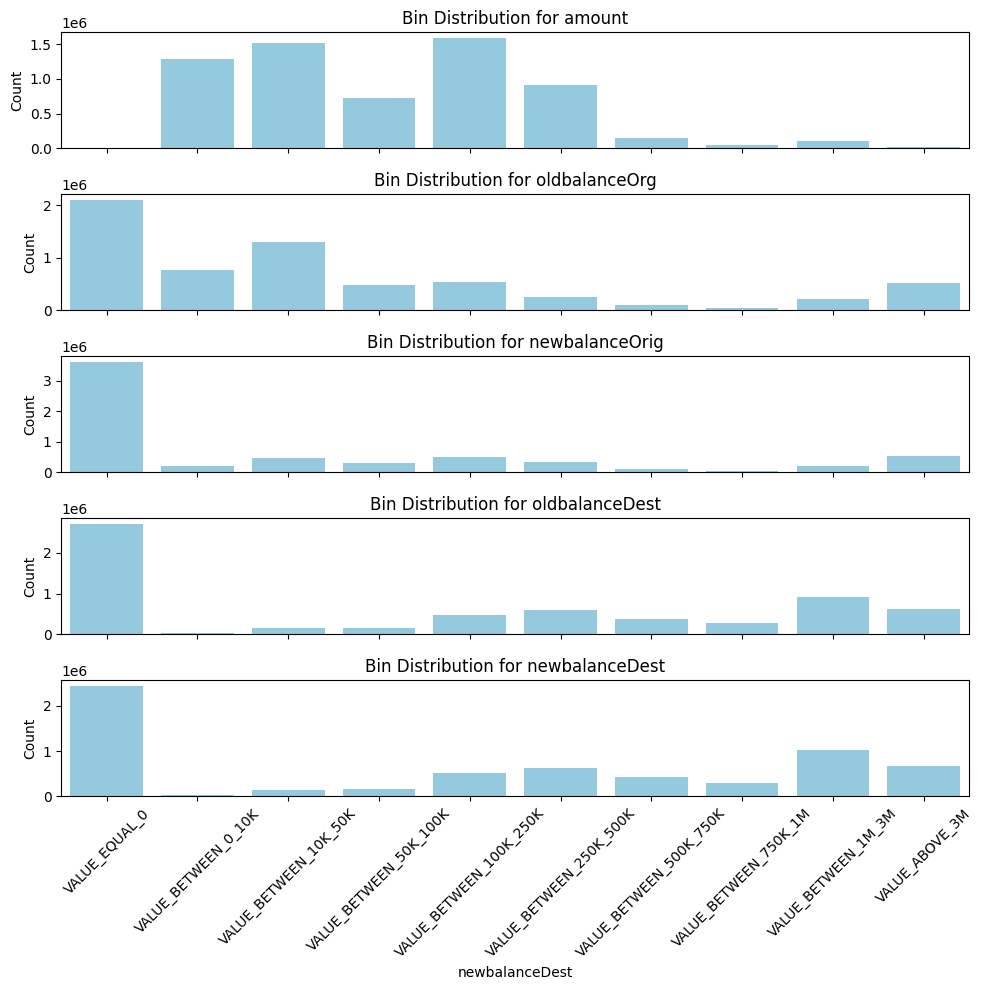

In [11]:
# Plot categorical count plots
fig, axes = plt.subplots(len(monetary_cols), 1, figsize=(10, 10), sharex=True)

for i, col in enumerate(monetary_cols):
    counts = binned_df[col].value_counts().reindex(VALUE_LABELS, fill_value=0)
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Bin Distribution for {col}")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [12]:
num_cols_train = df_raw_train.select_dtypes(include=["number"]).columns

for col in num_cols_train:
    df_raw_train[col] = bin_values_column(df_raw_train[col])

num_cols_eval = df_raw_eval.select_dtypes(include=["number"]).columns

for col in num_cols_eval:
    df_raw_eval[col] = bin_values_column(df_raw_eval[col])

num_cols_test = df_raw_test.select_dtypes(include=["number"]).columns

for col in num_cols_test:
    df_raw_test[col] = bin_values_column(df_raw_test[col])

In [13]:
df_raw_train.reset_index(drop=True, inplace=True)
df_raw_eval.reset_index(drop=True, inplace=True)
df_raw_test.reset_index(drop=True, inplace=True)

In [14]:
df_raw_train.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,hour_of_transaction
0,PAYMENT,VALUE_BETWEEN_10K_50K,VALUE_BETWEEN_50K_100K,VALUE_BETWEEN_10K_50K,VALUE_EQUAL_0,VALUE_EQUAL_0,SYNTH_HOUR_14
1,CASH_IN,VALUE_BETWEEN_100K_250K,VALUE_ABOVE_3M,VALUE_ABOVE_3M,VALUE_BETWEEN_1M_3M,VALUE_BETWEEN_750K_1M,SYNTH_HOUR_20
2,PAYMENT,VALUE_BETWEEN_0_10K,VALUE_BETWEEN_100K_250K,VALUE_BETWEEN_100K_250K,VALUE_EQUAL_0,VALUE_EQUAL_0,SYNTH_HOUR_16
3,CASH_OUT,VALUE_BETWEEN_100K_250K,VALUE_BETWEEN_10K_50K,VALUE_EQUAL_0,VALUE_EQUAL_0,VALUE_BETWEEN_100K_250K,SYNTH_HOUR_20
4,TRANSFER,VALUE_BETWEEN_100K_250K,VALUE_EQUAL_0,VALUE_EQUAL_0,VALUE_BETWEEN_750K_1M,VALUE_BETWEEN_750K_1M,SYNTH_HOUR_18


# 2. Traditional ML

In [15]:
pipeline_hgb = Pipeline(
    steps=[
        (
            "encoder",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                categorical_features="from_dtype",
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

# Convert mapped columns to 'category' dtype for HistGradientBoosting
X_train_encoded = df_raw_train.astype("category")
pipeline_hgb.fit(X_train_encoded, labels_train)

Pipeline(steps=[('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('classifier',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                random_state=42))])

In [16]:
# 1. Convert test set columns to category dtype
X_test_encoded = df_raw_test.astype("category")
X_eval_encoded = df_raw_eval.astype("category")

# 2. Predict probability of fraud (class 1) — Recommended for imbalanced data
y_test_proba = pipeline_hgb.predict_proba(X_test_encoded)[:, 1]
y_eval_proba = pipeline_hgb.predict_proba(X_eval_encoded)[:, 1]

In [17]:
metrics_summary = evaluate_model_pipeline(
    y_eval_true=labels_eval,
    y_eval_probs=y_eval_proba,
    y_test_true=labels_test,
    y_test_probs=y_test_proba,
)

                  MODEL EVALUATION REPORT                   
Selected Threshold (from Eval): 0.95  (Eval F1: 0.5757)
------------------------------------------------------------
OVERALL PERFORMANCE (Test Set):
  • PR-AUC (Avg Precision) : 0.8625
  • ROC-AUC                : 0.9983
  • F1-Score               : 0.5799
  • Precision              : 0.4359
  • Recall                 : 0.8661
------------------------------------------------------------
CONFUSION MATRIX (Test Set):
  • True Negatives  (TN)   : 951,780
  • False Positives (FP)   : 1,381
  • False Negatives (FN)   : 165
  • True Positives  (TP)   : 1,067
------------------------------------------------------------
DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

      Normal     0.9998    0.9986    0.9992    953161
       Fraud     0.4359    0.8661    0.5799      1232

    accuracy                         0.9984    954393
   macro avg     0.7178    0.9323    0.7895    954393
weig

# 3. BERT

### Create vocabulary

In [18]:
special_tokens = {"[CLS]": 0, "[MASK]": 1, "[SEP]": 2}

transaction_types_tokens = df_raw_train["type"].unique().tolist()
value_bins_tokens = VALUE_LABELS
hour_of_transaction_tokens = df_raw_train["hour_of_transaction"].unique().tolist()

values_vocab = transaction_types_tokens + value_bins_tokens + hour_of_transaction_tokens

print("Number of Special Tokens:", len(special_tokens))
print("Number of Transaction Type Tokens:", len(transaction_types_tokens))
print("Number of Value Bin Tokens:", len(value_bins_tokens))
print("Number of Hour of Transaction Tokens:", len(hour_of_transaction_tokens))

vocab_size = (
    len(special_tokens)
    + len(transaction_types_tokens)
    + len(value_bins_tokens)
    + len(hour_of_transaction_tokens)
)

print("\nTotal Vocabulary Size:", vocab_size)

Number of Special Tokens: 3
Number of Transaction Type Tokens: 5
Number of Value Bin Tokens: 10
Number of Hour of Transaction Tokens: 24

Total Vocabulary Size: 42


In [19]:
values2tokens = {
    value: idx + len(special_tokens) for idx, value in enumerate(values_vocab)
}
token2values = {v: k for k, v in values2tokens.items()}

### Dataset for BERT

In [20]:
train_dataset = FraudMLMDataset(df_raw_train, values2tokens, special_tokens)
eval_dataset = FraudMLMDataset(df_raw_eval, values2tokens, special_tokens)
test_dataset = FraudMLMDataset(df_raw_test, values2tokens, special_tokens)

### Collator for MLM

In [21]:
collator = FraudDataCollatorForMLM(
    mask_token_id=special_tokens["[MASK]"],
    cls_token_id=special_tokens["[CLS]"],
    sep_token_id=special_tokens["[SEP]"],
    vocab_size=vocab_size,
    mlm_probability=0.15,
    num_special_tokens=len(special_tokens),
)

### Define and train model

In [22]:
config = BertConfig(
    vocab_size=vocab_size,
    hidden_size=64,
    num_hidden_layers=2,
    num_attention_heads=2,
    intermediate_size=128,
    max_position_embeddings=df_raw_train.shape[-1] + 2,  # [CLS] and [SEP] tokens
    type_vocab_size=1,
    pad_token_id=None,  # No padding token in this dataset since all sequences are of the same length
)

model = BertForMaskedLM(config)

In [23]:
training_args = TrainingArguments(
    output_dir="./fraud_bert_mlm",
    num_train_epochs=5,
    per_device_train_batch_size=256,
    per_device_eval_batch_size=512,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    weight_decay=0.01,
    warmup_steps=100,
    report_to="none",
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collator,
)

In [24]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,2.117669,2.004784
2,1.981888,1.884547
3,1.945325,1.843718
4,1.948402,1.825935
5,1.939192,1.821619


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['cls.predictions.decoder.weight', 'cls.predictions.decoder.bias'].


TrainOutput(global_step=46605, training_loss=2.0924866550381305, metrics={'train_runtime': 4436.7193, 'train_samples_per_second': 5377.808, 'train_steps_per_second': 10.504, 'total_flos': 91996518131100.0, 'train_loss': 2.0924866550381305, 'epoch': 5.0})

In [25]:
trainer.save_model("./fraud_bert_mlm_best")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Fine tuning on fraud binary classification

In [26]:
# Path to your best MLM checkpoint directory
mlm_checkpoint_path = "./fraud_bert_mlm_best"

# Load model weights into a Sequence Classification architecture
model = AutoModelForSequenceClassification.from_pretrained(
    mlm_checkpoint_path,
    num_labels=2,  # Binary classification (0: normal, 1: fraud)
)

Loading weights:   0%|          | 0/37 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./fraud_bert_mlm_best
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [27]:
supervised_train_dataset = FraudClassificationDataset(
    df_raw_train, values2tokens, special_tokens, labels_train
)
supervised_eval_dataset = FraudClassificationDataset(
    df_raw_eval, values2tokens, special_tokens, labels_eval
)
supervised_test_dataset = FraudClassificationDataset(
    df_raw_test, values2tokens, special_tokens, labels_test
)

In [28]:
training_args = TrainingArguments(
    output_dir="./fraud_bert_classification",
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,  # Lower learning rate for fine-tuning
    per_device_train_batch_size=256,
    per_device_eval_batch_size=512,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    metric_for_best_model="pr_auc",  # Ideal metric for imbalanced fraud datasets
    greater_is_better=True,
    load_best_model_at_end=True,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=supervised_train_dataset,  # Dataset yielding 'input_ids', 'attention_mask', and 'labels'
    eval_dataset=supervised_eval_dataset,
    compute_metrics=compute_metrics,  # Custom function for Precision, Recall, F1
)

In [29]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Pr Auc,Roc Auc
1,0.006983,0.005355,0.775681,0.909836,0.676005,0.788780,0.989872
2,0.005214,0.003954,0.828866,0.951104,0.734470,0.839415,0.994427
3,0.004490,0.003597,0.842250,0.963893,0.747868,0.851873,0.995774
4,0.004061,0.003474,0.842466,0.962441,0.749086,0.857771,0.996369
5,0.004051,0.003374,0.850034,0.948949,0.769793,0.858493,0.996432


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta', 'bert.encoder.layer.1.attention.output.LayerNorm.gamma', 'bert.en

TrainOutput(global_step=46605, training_loss=0.01794765555747345, metrics={'train_runtime': 4691.7864, 'train_samples_per_second': 5085.446, 'train_steps_per_second': 9.933, 'total_flos': 91944980909100.0, 'train_loss': 0.01794765555747345, 'epoch': 5.0})

In [30]:
trainer.save_model("./fraud_bert_classification_best")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [31]:
test_results = trainer.predict(supervised_test_dataset)
test_logits = test_results.predictions
test_labels = test_results.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1)[:, 1].numpy()

eval_results = trainer.predict(supervised_eval_dataset)
eval_logits = eval_results.predictions
eval_labels = eval_results.label_ids
eval_probs = torch.softmax(torch.tensor(eval_logits), dim=-1)[:, 1].numpy()

# print(test_results.metrics)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [32]:
metrics_summary = evaluate_model_pipeline(
    y_eval_true=eval_labels,
    y_eval_probs=eval_probs,
    y_test_true=test_labels,
    y_test_probs=test_probs,
)

                  MODEL EVALUATION REPORT                   
Selected Threshold (from Eval): 0.50  (Eval F1: 0.8500)
------------------------------------------------------------
OVERALL PERFORMANCE (Test Set):
  • PR-AUC (Avg Precision) : 0.8514
  • ROC-AUC                : 0.9968
  • F1-Score               : 0.8525
  • Precision              : 0.9632
  • Recall                 : 0.7646
------------------------------------------------------------
CONFUSION MATRIX (Test Set):
  • True Negatives  (TN)   : 953,125
  • False Positives (FP)   : 36
  • False Negatives (FN)   : 290
  • True Positives  (TP)   : 942
------------------------------------------------------------
DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

      Normal     0.9997    1.0000    0.9998    953161
       Fraud     0.9632    0.7646    0.8525      1232

    accuracy                         0.9997    954393
   macro avg     0.9814    0.8823    0.9262    954393
weighted 

### Finetune only head with Frozen BERT

In [33]:
frozen_model = AutoModelForSequenceClassification.from_pretrained(
    mlm_checkpoint_path,
    num_labels=2,  # Binary classification (0: normal, 1: fraud)
)

# 1. Freeze all base BERT parameters
for param in frozen_model.bert.parameters():
    param.requires_grad = False

# 2. Verify which parameters are still trainable
for name, param in frozen_model.named_parameters():
    if param.requires_grad:
        print(f"Trainable layer: {name}")

Loading weights:   0%|          | 0/37 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./fraud_bert_mlm_best
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable layer: classifier.weight
Trainable layer: classifier.bias


In [34]:
training_args = TrainingArguments(
    output_dir="./fraud_bert_classification_frozen",
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,  # Lower learning rate for fine-tuning
    per_device_train_batch_size=256,
    per_device_eval_batch_size=512,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    metric_for_best_model="pr_auc",  # Ideal metric for imbalanced fraud datasets
    greater_is_better=True,
    load_best_model_at_end=True,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=supervised_train_dataset,  # Dataset yielding 'input_ids', 'attention_mask', and 'labels'
    eval_dataset=supervised_eval_dataset,
    compute_metrics=compute_metrics,  # Custom function for Precision, Recall, F1
)

In [35]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Pr Auc,Roc Auc
1,0.003693,0.003085,0.853156,0.938596,0.781973,0.867155,0.996737
2,0.003873,0.003065,0.855438,0.938865,0.785627,0.868056,0.996347
3,0.003637,0.002988,0.859051,0.951183,0.783191,0.870199,0.995908
4,0.003489,0.002989,0.857715,0.949704,0.781973,0.870815,0.995834
5,0.003409,0.002961,0.859043,0.945827,0.786845,0.871051,0.995898


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta', 'bert.encoder.layer.1.attention.output.LayerNorm.gamma', 'bert.en

TrainOutput(global_step=46605, training_loss=0.003541198497856524, metrics={'train_runtime': 4744.9958, 'train_samples_per_second': 5028.419, 'train_steps_per_second': 9.822, 'total_flos': 91944980909100.0, 'train_loss': 0.003541198497856524, 'epoch': 5.0})

In [36]:
trainer.save_model("./fraud_bert_classification_frozen_best")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [37]:
test_results = trainer.predict(supervised_test_dataset)
test_logits = test_results.predictions
test_labels = test_results.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1)[:, 1].numpy()

eval_results = trainer.predict(supervised_eval_dataset)
eval_logits = eval_results.predictions
eval_labels = eval_results.label_ids
eval_probs = torch.softmax(torch.tensor(eval_logits), dim=-1)[:, 1].numpy()

# print(test_results.metrics)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [38]:
metrics_summary = evaluate_model_pipeline(
    y_eval_true=eval_labels,
    y_eval_probs=eval_probs,
    y_test_true=test_labels,
    y_test_probs=test_probs,
)

                  MODEL EVALUATION REPORT                   
Selected Threshold (from Eval): 0.50  (Eval F1: 0.8590)
------------------------------------------------------------
OVERALL PERFORMANCE (Test Set):
  • PR-AUC (Avg Precision) : 0.8638
  • ROC-AUC                : 0.9967
  • F1-Score               : 0.8592
  • Precision              : 0.9599
  • Recall                 : 0.7776
------------------------------------------------------------
CONFUSION MATRIX (Test Set):
  • True Negatives  (TN)   : 953,121
  • False Positives (FP)   : 40
  • False Negatives (FN)   : 274
  • True Positives  (TP)   : 958
------------------------------------------------------------
DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

      Normal     0.9997    1.0000    0.9998    953161
       Fraud     0.9599    0.7776    0.8592      1232

    accuracy                         0.9997    954393
   macro avg     0.9798    0.8888    0.9295    954393
weighted 